In [1]:
import sys
import torch
import polars as pl

from modeling_module.data_loader.MultiPartDataModule import MultiPartDataModule

'''
pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
https://developer.nvidia.com/cuda-12-8-0-download-archive
'''

MAC_DIR = '/Users/igwanhyeong/PycharmProjects/data_research/raw_data/'
WINDOW_DIR = 'C:/Users/USER/PycharmProjects/research/raw_data/'

if sys.platform == 'win32':
    DIR = WINDOW_DIR
    print(torch.cuda.is_available())
    print(torch.cuda.device_count())
    print(torch.version.cuda)
    print(torch.__version__)
    print(torch.cuda.get_device_name(0))
    print(torch.__version__)
else:
    DIR = MAC_DIR

True
1
12.8
2.9.0.dev20250716+cu128
NVIDIA GeForce RTX 5080
2.9.0.dev20250716+cu128


In [2]:
target_dyn_demand_weekly = pl.read_parquet(DIR + 'target_dyn_demand_weekly.parquet').sort(['oper_part_no', 'demand_dt'])
target_dyn_demand_weekly

oper_part_no,demand_dt,demand_qty
str,i64,f64
"""0001-1001""",201811,5.0
"""0001-1001""",201847,7.0
"""0001-1001""",202005,20.0
"""0001-1001""",202006,100.0
"""0001-1001""",202010,2.0
…,…,…
"""ZZ90239""",202043,1.0
"""ZZ90239""",202145,1.0
"""ZZ90239""",202325,1.0


In [3]:
from modeling_module.models.PatchTST.supervised.backbone import SupervisedBackbone
from modeling_module.models.PatchTST.common.configs import PatchTSTConfigWeekly

cfg = PatchTSTConfigWeekly(
    c_in=1,
    target_dim=1,
    lookback=54,
    horizon=27,
    patch_len=4,
    stride=2,
)

model = SupervisedBackbone(cfg)
x = torch.randn(8, cfg.c_in, cfg.lookback)
out = model(x)

print(out.shape)  # [8, L_tok, d_model]

torch.Size([8, 26, 128])


In [4]:
plan_yyyymm = 201811
lookback = 54
horizon = 27

data_module = MultiPartDataModule(
    target_dyn_demand_weekly.sort(['oper_part_no', 'demand_dt']),
    lookback = lookback,
    horizon = horizon,
    batch_size = 64,
    val_ratio = 0.2,
    is_running = True
)

train_loader = data_module.get_train_loader()
val_loader = data_module.get_val_loader()

In [5]:
from modeling_module.training.model_trainers.total_train import run_total_train_monthly

mode_dict = run_total_train_monthly(
    train_loader,
    val_loader,
    lookback = lookback,
    horizon = horizon,
)

PatchMixer Base


C:\Users\USER\python\py312\Lib\site-packages\torch\nn\modules\conv.py:366: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1028.)
  return F.conv1d(


Epoch 1/100 | LR 0.000976 | Train 33.751464 | Val 32.868318
Epoch 2/100 | LR 0.000905 | Train 33.123661 | Val 32.681817
Epoch 3/100 | LR 0.000794 | Train 33.042275 | Val 32.650854
Epoch 4/100 | LR 0.000655 | Train 32.973765 | Val 32.635500
Epoch 5/100 | LR 0.000500 | Train 32.902867 | Val 32.583579
Epoch 6/100 | LR 0.000345 | Train 32.846138 | Val 32.569268
Epoch 7/100 | LR 0.000206 | Train 32.804674 | Val 32.562990
Epoch 8/100 | LR 0.000095 | Train 32.754129 | Val 32.532341
Epoch 9/100 | LR 0.000024 | Train 32.715973 | Val 32.527031
Epoch 10/100 | LR 0.000000 | Train 32.687583 | Val 32.533468
Epoch 11/100 | LR 0.000024 | Train 32.680613 | Val 32.535180
Epoch 12/100 | LR 0.000095 | Train 32.688396 | Val 32.525313
Epoch 13/100 | LR 0.000206 | Train 32.692443 | Val 32.526542
Epoch 14/100 | LR 0.000345 | Train 32.706007 | Val 32.528666
Epoch 15/100 | LR 0.000500 | Train 32.720439 | Val 32.533576
Epoch 16/100 | LR 0.000655 | Train 32.738885 | Val 32.552096
Epoch 17/100 | LR 0.000794 | Trai

In [6]:
from modeling_module.utils.checkpoint import save_model_dict, load_model_dict
from modeling_module.utils.exogenous_utils import calendar_cb
from modeling_module.models.PatchTST.common.configs import PatchTSTConfigMonthly
from modeling_module.models.Titan.common.configs import TitanConfigMonthly, TitanConfigPatchMonthly
from modeling_module.models.PatchMixer.common.configs import PatchMixerConfigMonthly

save_dir = DIR + 'fit/20251104_running'
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

pm_base_config = PatchMixerConfigMonthly(
        device = device,
        loss_mode = 'point',
        point_loss = 'mae'
    )

pm_quantile_config = PatchMixerConfigMonthly(
    device = device,
    loss_mode = 'quantile',
    quantiles = (0.1, 0.5, 0.9)
)

# ti_config = TitanConfigMonthly(
#         device = device,
#         loss_mode = 'point',
#         point_loss = 'mae'
#     )
#
# ti_patch_config = TitanConfigPatchMonthly(
#     device = device,
#     loss_mode = 'point',
#     point_loss = 'mae'
# )
#
# pt_config = PatchTSTConfigMonthly(
#         device = device,
#         loss_mode = 'auto',
#         quantiles = (0.1, 0.5, 0.9)
#     )

cfg_map = {
    "PatchMixer Base": pm_base_config,
    "PatchMixer Quantile": pm_quantile_config,
    # "Titan Base": ti_config,
    # "Titan LMM": ti_config,
    # "Titan Seq2Seq": ti_config,
    # "Titan Patch": ti_patch_config,
    # "PatchTST Base": pt_config,
    # "PatchTST Quantile": pt_config
}

builder_key_by_name = {
  "PatchMixer Base": "patchmixer_base",
  "PatchMixer Quantile": "patchmixer_quantile",
  # "Titan Base": "titan_base",
  # "Titan LMM": "titan_lmm",
  # "Titan Seq2Seq": "titan_seq2seq",
  # "Titan Patch": "titan_patch",
  # "PatchTST Base": "patchtst_base",
  # "PatchTST Quantile": "patchtst_quantile",
}
save_index = save_model_dict(mode_dict, save_dir, cfg_by_name = cfg_map, builder_key_by_name=builder_key_by_name)

# Load
from modeling_module.models.model_builder import (
    build_patch_mixer_base, build_patch_mixer_quantile,
    build_titan_base, build_titan_lmm, build_titan_seq2seq,
    build_patchTST_base, build_patchTST_quantile, build_titan_patch,
)

builders = {
    "patchmixer_base": lambda cfg: build_patch_mixer_base(cfg or PatchMixerConfigMonthly()),
    "patchmixer_quantile": lambda cfg: build_patch_mixer_quantile(cfg or PatchMixerConfigMonthly()),
    # "titan_base": lambda cfg: build_titan_base(cfg or TitanConfigMonthly()),
    # "titan_lmm": lambda cfg: build_titan_lmm(cfg or TitanConfigMonthly()),
    # "titan_seq2seq": lambda cfg: build_titan_seq2seq(cfg or TitanConfigMonthly()),
    # 'titan_patch': lambda cfg: build_titan_patch(cfg or TitanConfigPatchMonthly()),
    # "patchtst_base": lambda cfg: build_patchTST_base(cfg or PatchTSTConfigMonthly()),
    # "patchtst_quantile": lambda cfg: build_patchTST_quantile(cfg or PatchTSTConfigMonthly()),
}
loaded = load_model_dict(save_dir, builders, device = device)



[load] patchmixer_base ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251104_running\patchmixer_base.pt
[load] patchmixer_quantile ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251104_running\patchmixer_quantile.pt


In [ ]:
model = loaded["patchmixer_base"].to(device).eval()
x1 = next(iter(val_loader))[0][:1].to(device)   # [1, L, C] or [1, L]

with torch.no_grad():
    x_n   = model.revin(x1, 'norm')
    z     = model.backbone(x_n)
    x_bhf = model.expander(z)
    x_bhf_n = model.pre_ln(x_bhf)
    resid = model.head(x_bhf_n).squeeze(-1)

    # base/alpha
    H = model.horizon
    t = torch.linspace(-1, 1, H, device=z.device).unsqueeze(0)
    b = model.base_head_b(z); m = model.base_head_m(z)
    base  = b + m * t
    alpha = torch.sigmoid(model.base_gate(z)).expand(-1, H)

    # gate
    xg = model.gate_ln(x_bhf_n).transpose(1,2)
    g1 = model.gate_act(model.gate_conv_3(xg))
    g2 = model.gate_act(model.gate_conv_5(xg))
    g3 = model.gate_act(model.gate_conv_d3(xg))
    glogit = model.gate_reduce(torch.cat([g1,g2,g3], 1)).transpose(1,2).squeeze(-1)
    tau = torch.linspace(-1,1,H,device=z.device).view(1,H).expand(z.size(0),H)
    glogit = model.g_gain * ((glogit + model.tau_weight * tau + model.g_bias) / model.gate_temp)
    gate = torch.sigmoid(torch.clamp(glogit, -model.g_logit_clip, model.g_logit_clip))

print("resid var(H) mean:", resid.var(dim=1).mean().item())
print("gate mean/std:", gate.mean().item(), gate.std().item())
print("alpha mean:", alpha.mean().item())

[FCAST-DBG] DMS block: Hm=27, var(Hm)=4.36734, first5=[4.13239, 6.32592, 10.7877, 9.11037, 7.25174]
[FCAST-DBG] DONE: H=27, var=4.36734, first5=[4.13239, 6.32592, 10.7877, 9.11037, 7.25174]
[PLOT-DBG] patchmixer_base point(H=27): var(H)=4.20558, mean(H)=7.37833, unique(H)=27
[PLOT-DBG] patchmixer_quantile point(H=27): var(H)=0.302182, mean(H)=6.97915, unique(H)=27


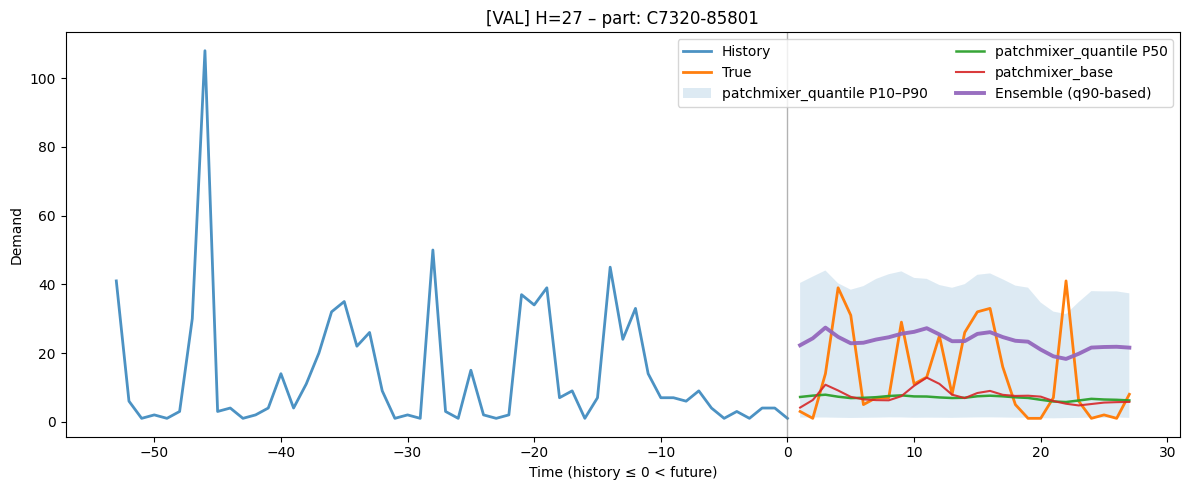

[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.15629, first5=[3.95588, 3.79418, 3.90197, 4.04588, 3.76841]
[FCAST-DBG] DONE: H=27, var=0.15629, first5=[3.95588, 3.79418, 3.90197, 4.04588, 3.76841]
[PLOT-DBG] patchmixer_base point(H=27): var(H)=0.150502, mean(H)=4.02169, unique(H)=27
[PLOT-DBG] patchmixer_quantile point(H=27): var(H)=0.0410448, mean(H)=4.39069, unique(H)=27


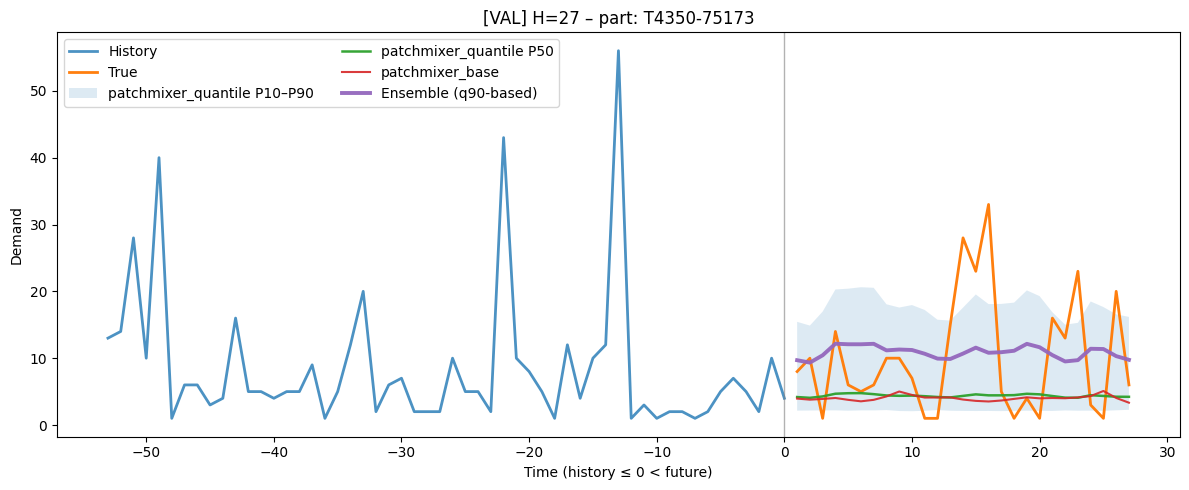

[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.286673, first5=[3.98087, 2.44726, 1.75998, 1.7736, 1.92981]
[FCAST-DBG] DONE: H=27, var=0.286673, first5=[3.98087, 2.44726, 1.75998, 1.7736, 1.92981]
[PLOT-DBG] patchmixer_base point(H=27): var(H)=0.276055, mean(H)=1.9988, unique(H)=27
[PLOT-DBG] patchmixer_quantile point(H=27): var(H)=0.0227908, mean(H)=2.00939, unique(H)=27


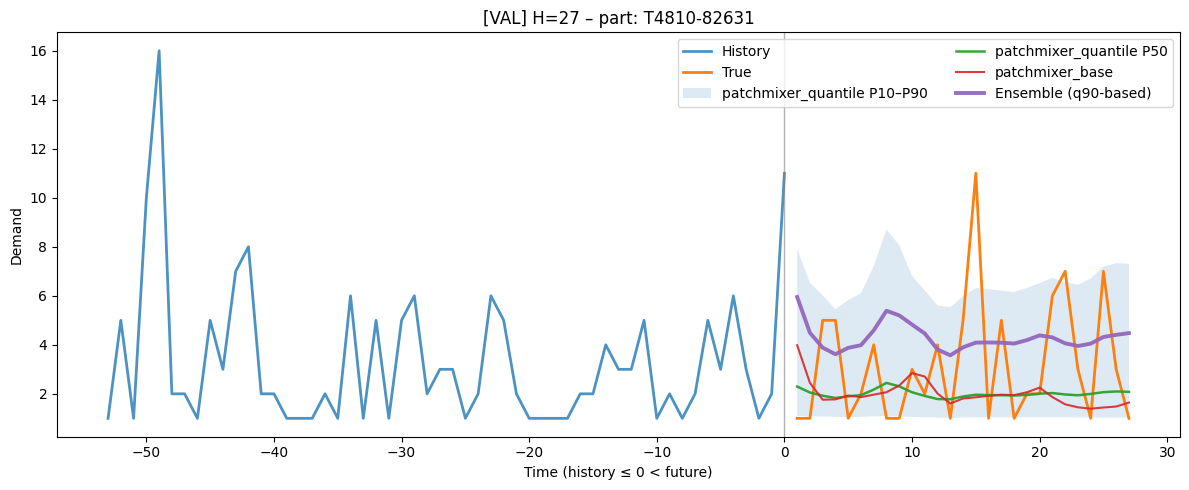

[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.177091, first5=[3.01429, 1.98665, 1.43131, 1.84883, 2.3193]
[FCAST-DBG] DONE: H=27, var=0.177091, first5=[3.01429, 1.98665, 1.43131, 1.84883, 2.3193]
[PLOT-DBG] patchmixer_base point(H=27): var(H)=0.170532, mean(H)=2.32489, unique(H)=27
[PLOT-DBG] patchmixer_quantile point(H=27): var(H)=0.173417, mean(H)=2.20214, unique(H)=27


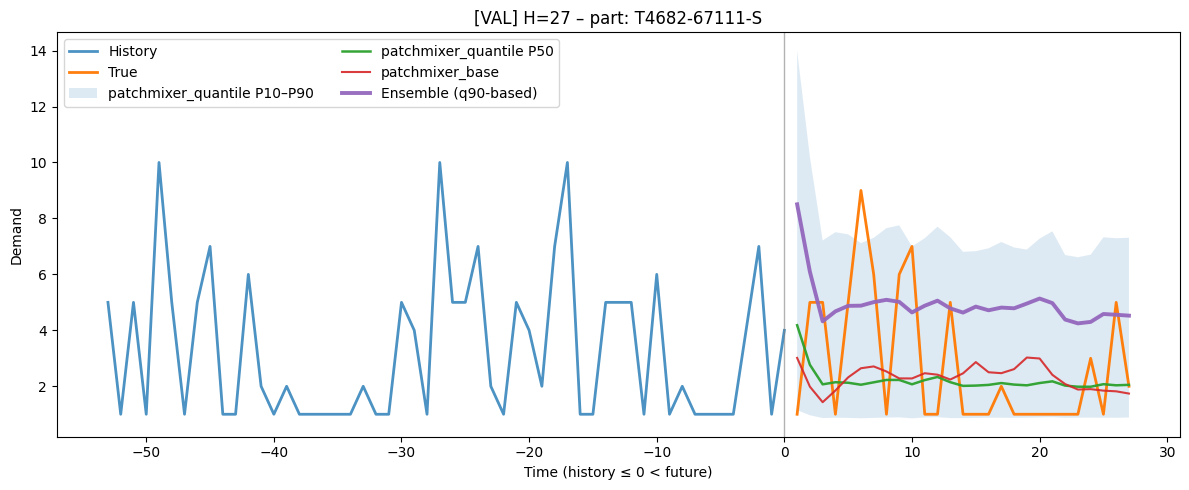

[FCAST-DBG] DMS block: Hm=27, var(Hm)=18.9255, first5=[16.4673, 18.908, 21.2136, 18.139, 17.1699]
[FCAST-DBG] DONE: H=27, var=18.9255, first5=[16.4673, 18.908, 21.2136, 18.139, 17.1699]
[PLOT-DBG] patchmixer_base point(H=27): var(H)=18.2245, mean(H)=12.5344, unique(H)=27
[PLOT-DBG] patchmixer_quantile point(H=27): var(H)=2.59215, mean(H)=11.7857, unique(H)=27


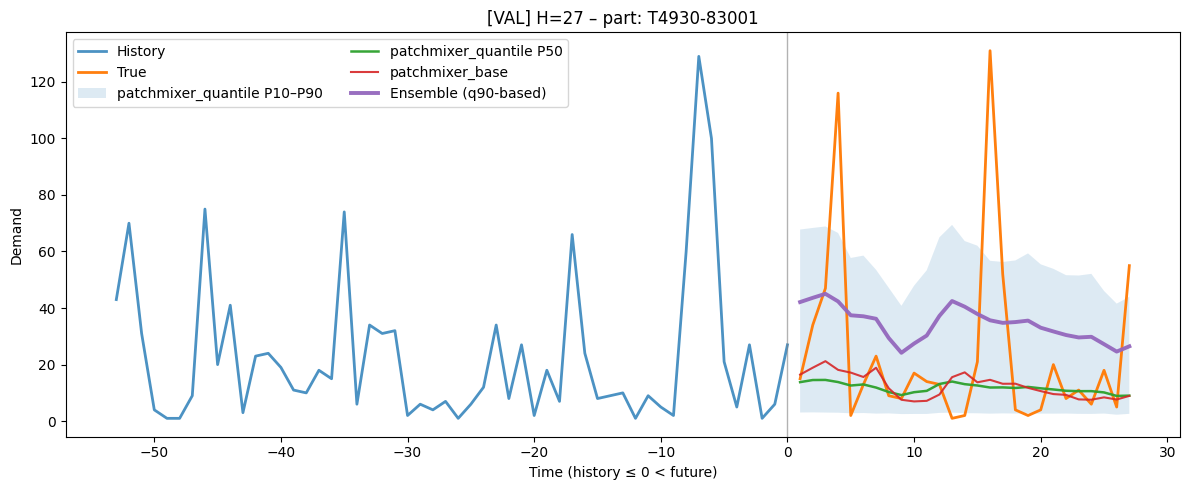

In [7]:
%load_ext autoreload
%autoreload 2

import importlib, modeling_module.utils.plot_utils as pu
import modeling_module.training.forecaster as fo
importlib.reload(pu)
importlib.reload(fo)

def my_exo_cb(start_idx: int, Hm: int, device="cuda" if torch.cuda.is_available() else "cpu"):
    # exo_dim = 2 (sin, cos)
    return fo.make_calendar_exo(start_idx, Hm, period=52, device=device)

pu.plot_27w(
    models=loaded,           # {"PatchMixer": pm_model, "Titan": ti_model, ...}
    loader=val_loader,       # (xb, yb[, part_ids])
    device="cuda" if torch.cuda.is_available() else "cpu",
    mode="val",              # ← 검증 모드
    max_plots=5,
    out_dir=None,
    show=True,
    future_exo_cb=my_exo_cb
)

In [ ]:
import importlib
from modeling_module.utils import temporal_expander as te
from modeling_module.models.PatchMixer import PatchMixer as pm

te  = importlib.reload(te)   # Expander 변경 반영
pm  = importlib.reload(pm)   # PatchMixer 변경 반영
old = loaded['patchmixer_base']        # 예전 인스턴스
sd  = old.state_dict()                  # 가중치만 백업
cfg = pm_base_config  # 같은 horizon/enc_in 등
exo_dim = getattr(old, 'exo_dim', 0)

new_model = pm.BaseModel(configs=cfg, exo_dim=exo_dim)
missing, unexpected = new_model.load_state_dict(sd, strict=False)
print("missing:", missing)       # 새로 추가된 레이어들은 여기로 나옵니다(정상)
print("unexpected:", unexpected) # 구조가 바뀐 옛 키(예: fc.*)는 여기로(정상)

import torch.nn as nn
if hasattr(new_model, 'out_scale'): new_model.out_scale.data.fill_(1.0)
if hasattr(new_model, 'out_bias'):  new_model.out_bias.data.zero_()
if hasattr(new_model, 'step_gate_fc'):
    nn.init.constant_(new_model.step_gate_fc.bias, 0.5)

new_model = new_model.to(device).eval()
loaded['patchmixer_base'] = new_model
model = new_model   # 이후엔 이 객체로 사용

model.eval(); model.final_nonneg = False

def slope_mean(v):  # v: [B,H]
    return float((v[:, -1] - v[:, 0]).mean())

with torch.no_grad():
    x_n  = model.revin(x1, 'norm')
    z    = model.backbone(x_n)
    H    = model.horizon
    t    = torch.linspace(-1, 1, H, device=z.device).unsqueeze(0)

    b = model.base_head_b(z); m = model.base_head_m(z)
    base  = b + m * t
    alpha = torch.sigmoid(model.base_gate(z)).expand(-1, H)

    xbhf   = model.expander(z)
    xbhf_n = model.pre_ln(xbhf)
    resid  = model.head(xbhf_n).squeeze(-1)
    resid  = resid - resid.mean(dim=1, keepdim=True)   # 추가한 줄과 맞춤
    resid  = resid * float(model.resid_scale)

    xg = model.gate_ln(xbhf_n).transpose(1,2)
    g1 = model.gate_act(model.gate_conv_3(xg))
    g2 = model.gate_act(model.gate_conv_5(xg))
    g3 = model.gate_act(model.gate_conv_d3(xg))
    gcat   = model.gate_do(torch.cat([g1,g2,g3], dim=1))
    glogit = model.gate_reduce(gcat).transpose(1,2).squeeze(-1)
    # τ 영향 제거한 상태라면 tau_weight=0
    tau    = torch.linspace(-1, 1, H, device=z.device).view(1,H).expand(z.size(0),H)
    glogit = model.g_gain * ((glogit + model.tau_weight * tau + model.g_bias) / model.gate_temp)
    glogit = torch.clamp(glogit, -model.g_logit_clip, model.g_logit_clip)
    gate   = torch.sigmoid(glogit)
    gate   = gate - gate.mean(dim=1, keepdim=True) + 0.5
    gate   = torch.clamp(gate, 0.05, 0.95)

    resid_part = (1.0 - alpha) * (gate * resid)
    y_n = alpha * base + resid_part

    print("alpha mean:", float(alpha.mean()))
    print("m mean:", float(m.mean()))
    print("base slope(mean):", slope_mean(base))
    print("resid_part slope(mean):", slope_mean(resid_part))
    print("y slope(mean):", slope_mean(y_n))


In [ ]:
# plan_yyyyww 기준으로 과거 히스토리 + 27주 예측을 그림
# pu.plot_27w(
#     models=loaded,
#     loader=inference_loader,  # (xb, part_ids)
#     device="cuda",
#     mode="infer",             # ← 추론 모드
#     plan_yyyyww=202544,       # 앵커 주차(예: 2025년 44주)
#     max_plots=10,
#     out_dir=None,
#     show=True,
#     future_exo_cb=my_exo_cb,
#     # 필요하면 GT를 불러오는 콜백(옵션)
#     truth_cb=None            # 또는 truth_cb(part_id, plan_dt, H=27, 'week') -> np.ndarray
# )

In [ ]:
# pu.plot_120m(
#     models=loaded,
#     loader=val_loader,       # (xb, yb[, part_ids])
#     device="cuda",
#     mode="val",
#     max_plots=5,
#     out_dir=None,
#     show=True,
#     future_exo_cb=my_exo_cb
# )

In [ ]:
# pu.plot_120m(
#     models=loaded,
#     loader=inference_loader,  # (xb, part_ids)
#     device="cuda",
#     mode="infer",
#     plan_yyyymm=202510,       # 앵커 월(예: 2025년 10월)
#     max_plots=10,
#     out_dir=None,
#     show=True,
#     future_exo_cb=my_exo_cb,
#     # 필요하면 월 단위 GT 조회 콜백
#     truth_cb=None            # 또는 truth_cb(part_id, plan_dt, H=120, 'month') -> np.ndarray
# )